# Task 3: A/B Hypothesis Testing
## Statistical Validation of Risk Drivers for ACIS Segmentation Strategy

**Objective:** Statistically validate or reject key hypotheses about risk drivers across provinces, zip codes, and demographics to form the evidence base for ACIS's new segmentation and pricing strategy.

## Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, poisson, norm

# Reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Import Reusable Test Functions

In [25]:
import sys
import os

# Add project root
sys.path.append(
    os.path.abspath("..")
)

from src.hypothesis_tests import (
    run_anova_test,
    run_ttest,
    run_chi_square_test
)

print("Reusable hypothesis test functions loaded.")

Reusable hypothesis test functions loaded.


## Load Insurance Dataset

In [26]:
df = pd.read_csv(
    "../data/cleaned_insurance_data.csv"
)

C:\Users\simbog\AppData\Local\Temp\ipykernel_5188\2364633198.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [27]:
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000098, 53)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,YearMonth
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,2015-03
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,2015-05
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,2015-07
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,2015-05
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,2015-07


## Create Insurance KPIs

### Claim Indicator

Used for Claim Frequency.

In [28]:
df["HasClaim"] = np.where(
    df["TotalClaims"] > 0,
    1,
    0
)

### Loss Ratio

Insurance profitability metric:

Loss Ratio = TotalClaims​ / TotalPremium

In [29]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

# Remove invalid values
df_clean = df[df["LossRatio"].notna() & np.isfinite(df["LossRatio"])]

df_clean[["LossRatio"]].describe()

,LossRatio
count,618176.000000
mean,0.350048
std,9.288639
min,-18.700122
25%,0.000000
50%,0.000000
75%,0.000000
max,2553.600000


### Margin

Profitability metric:

Margin=TotalPremium−TotalClaims

In [30]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

### Claim Severity

Average claim amount when claim occurs.

Claim Severity= TotalClaims/Number of Claims
​


In [31]:
df["ClaimSeverity"] = np.where(
    df["TotalClaims"] > 0,
    df["TotalClaims"],
    np.nan
)

## Dataset Summary

In [32]:
print("=== Dataset Summary ===")

print("\nGender Distribution")
print(df["Gender"].value_counts())

print("\nProvince Distribution")
print(df["Province"].value_counts().head(10))

print("\nVehicle Type Distribution")
print(df["VehicleType"].value_counts())

print("\nNumerical Summary")
display(
    df[[
        "TotalPremium",
        "TotalClaims",
        "LossRatio",
        "Margin"
    ]].describe().round(2)
)

=== Dataset Summary ===

Gender Distribution
Gender
Not specified    940990
Male              42817
Female             6755
Name: count, dtype: int64

Province Distribution
Province
Gauteng          393865
Western Cape     170796
KwaZulu-Natal    169781
North West       143287
Mpumalanga        52718
Eastern Cape      30336
Limpopo           24836
Free State         8099
Northern Cape      6380
Name: count, dtype: int64

Vehicle Type Distribution
VehicleType
Passenger Vehicle    933598
Medium Commercial     53985
Heavy Commercial       7401
Light Commercial       3897
Bus                     665
Name: count, dtype: int64

Numerical Summary


,TotalPremium,TotalClaims,LossRatio,Margin
count,1000098.00,1000098.00,618176.00,1000098.00
mean,61.91,64.86,0.35,-2.96
std,230.28,2384.07,9.29,2367.14
min,-782.58,-12002.41,-18.70,-392848.57
25%,0.00,0.00,0.00,0.00
50%,2.18,0.00,0.00,2.16
75%,21.93,0.00,0.00,21.93
max,65282.60,393092.11,2553.60,65282.60


## Statistical Distributions

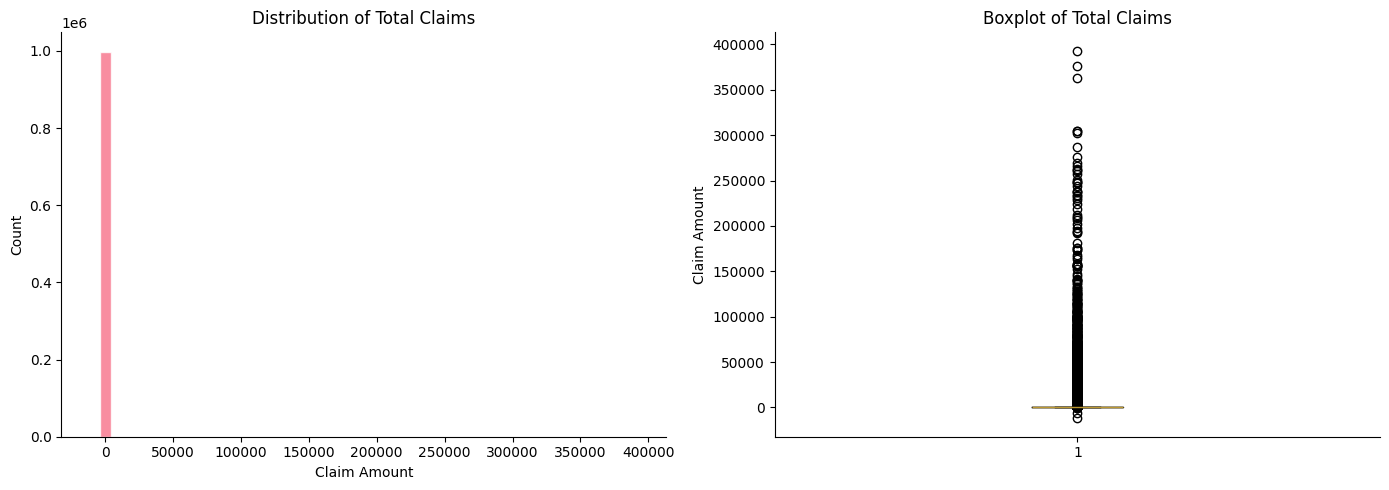

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram
ax = axes[0]

ax.hist(
    df["TotalClaims"],
    bins=50,
    edgecolor="white",
    alpha=0.8
)

ax.set_title("Distribution of Total Claims")
ax.set_xlabel("Claim Amount")
ax.set_ylabel("Count")

# Boxplot
ax2 = axes[1]

ax2.boxplot(
    df["TotalClaims"],
    vert=True
)

ax2.set_title("Boxplot of Total Claims")
ax2.set_ylabel("Claim Amount")

plt.tight_layout()
plt.show()

## Hypothesis Testing

### HYPOTHESIS 1
H₀: There are no risk differences across provinces

KPI: Loss Ratio

TEST: ANOVA

In [34]:
result_1 = run_anova_test(
    df=df_clean,
    group_col="Province",
    target_col="LossRatio"
)

print("\n" + "="*60)
print("HYPOTHESIS 1 — PROVINCE RISK DIFFERENCE")
print("="*60)

for k, v in result_1.items():
    print(f"{k}: {v}")


HYPOTHESIS 1 — PROVINCE RISK DIFFERENCE
Test: ANOVA
F-Statistic: 4.9692
P-Value: 3.5625050152170825e-06
Decision: Reject H0


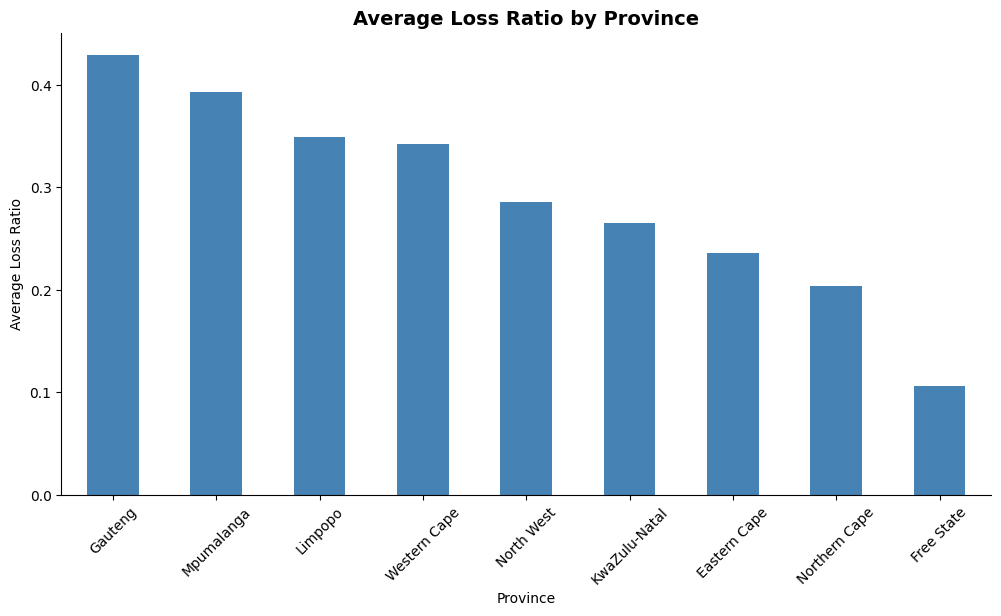

In [35]:
province_lr = (
    df_clean
    .groupby("Province")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

province_lr.plot(
    kind="bar",
    color="steelblue"
)

plt.title(
    "Average Loss Ratio by Province",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Loss Ratio")
plt.xlabel("Province")

plt.xticks(rotation=45)

plt.show()

## HYPOTHESIS 2
  H₀: There are no risk differences between postal codes
  
  KPI: Claim Frequency
  
  TEST: Chi-Square

In [36]:
# Select two postal codes
zip_df = df.groupby("PostalCode").filter(lambda x: x.name in [2000, 8000])
    

# Contingency Table
zip_table = pd.crosstab(
    zip_df["PostalCode"],
    zip_df["HasClaim"]
)

# Run Chi-Square Test
chi2_2, p_value_2, dof_2, expected_2 = chi2_contingency(zip_table)
print("\n" + "="*60)
print("HYPOTHESIS 2 — ZIP CODE RISK DIFFERENCE")
print("="*60)
print(f"Chi-Square  : {chi2_2:.4f}")
print(f"P-Value     : {p_value_2:.6f}")

if p_value_2 < 0.05:
    print("Decision    : Reject H₀")
else:
    print("Decision    : Fail to Reject H₀")



HYPOTHESIS 2 — ZIP CODE RISK DIFFERENCE
Chi-Square  : 1.1963
P-Value     : 0.274056
Decision    : Fail to Reject H₀


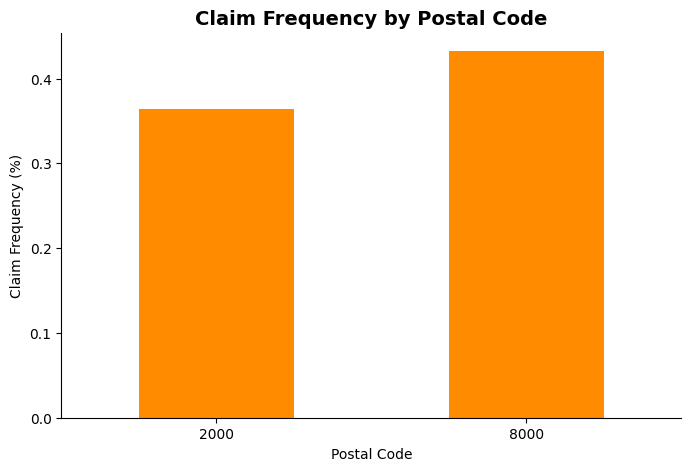

In [37]:
zip_claims = (
    zip_df
    .groupby("PostalCode")["HasClaim"]
    .mean() * 100
)

plt.figure(figsize=(8,5))

zip_claims.plot(
    kind="bar",
    color="darkorange"
)

plt.title(
    "Claim Frequency by Postal Code",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Claim Frequency (%)")
plt.xlabel("Postal Code")

plt.xticks(rotation=0)

plt.show()

## HYPOTHESIS 3
H₀: There is no significant margin difference between postal codes

KPI: Margin

TEST: Independent T-Test

In [38]:
# Recreate cleaned dataframe after KPI creation
df_clean = df[
    df["LossRatio"].notna() &
    np.isfinite(df["LossRatio"])
].copy()

print(df_clean.columns)

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims', 'YearMonth', 'HasClaim', 'LossRatio', 'Margin',
       'ClaimSeverity'],
      dtype='str')


In [39]:
result_3 = run_ttest(
    df=df_clean,
    group_col="PostalCode",
    target_col="Margin",
    group_a=2000,
    group_b=8000
)

print("\n" + "="*60)
print("HYPOTHESIS 3 — MARGIN DIFFERENCE BETWEEN POSTAL CODES")
print("="*60)

for k, v in result_3.items():
    print(f"{k}: {v}")


HYPOTHESIS 3 — MARGIN DIFFERENCE BETWEEN POSTAL CODES
Test: T-Test
T-Statistic: 0.2443
P-Value: 0.8070167052732052
Decision: Fail to Reject H0


## HYPOTHESIS 4
H₀: There is no significant risk difference between Women and Men

KPI: Claim Severity

TEST: Independent T-Test

In [40]:
gender_df = df[
    df["Gender"].isin(["Male", "Female"])
]
result_4 = run_ttest(
    df=gender_df,
    group_col="Gender",
    target_col="ClaimSeverity",
    group_a="Male",
    group_b="Female"
)

print("\n" + "="*60)
print("HYPOTHESIS 4 — GENDER RISK DIFFERENCE")
print("="*60)

for k, v in result_4.items():
    print(f"{k}: {v}")


HYPOTHESIS 4 — GENDER RISK DIFFERENCE
Test: T-Test
T-Statistic: -0.579
P-Value: 0.5680286951630672
Decision: Fail to Reject H0


In [41]:
if result_4["P-Value"] < 0.05:
    print("Reject H0")
    print("Gender significantly affects insurance risk.")
else:
    print("Fail to reject H0")
    print("No statistically significant gender-based claim severity difference was found.")

Fail to reject H0
No statistically significant gender-based claim severity difference was found.


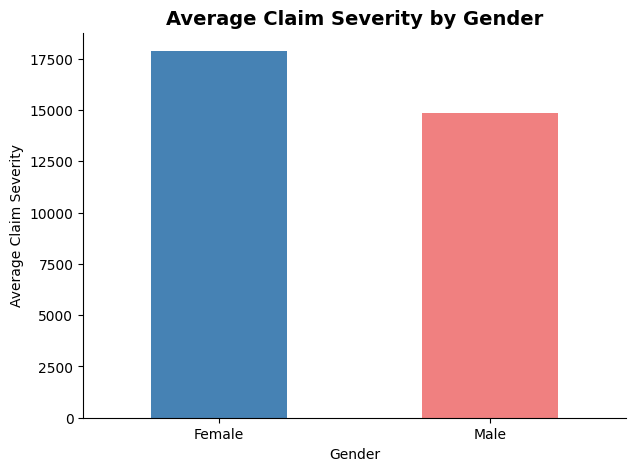

In [42]:
gender_claims = (
    gender_df
    .groupby("Gender")["ClaimSeverity"]
    .mean()
)

plt.figure(figsize=(7,5))

gender_claims.plot(
    kind="bar",
    color=["steelblue", "lightcoral"]
)

plt.title(
    "Average Claim Severity by Gender",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Claim Severity")
plt.xlabel("Gender")

plt.xticks(rotation=0)

plt.show()

In [43]:
## Final Results Summary

results_summary = pd.DataFrame([
    {
        "Hypothesis":
        "Risk Difference Across Provinces",

        "KPI":
        "Loss Ratio",

        "Test":
        
        result_1["Test"],

        "P-Value":
        result_1["P-Value"],

        "Decision":
        result_1["Decision"]
    },

    {
        "Hypothesis":
        "Risk Difference Between Postal Codes",

        "KPI":
        "Claim Frequency",

        "Test":
        "Chi-Square",

        "P-Value":
        p_value_2,

        "Decision":
        (
            "Reject H0"
            if p_value_2 < 0.05
            else "Fail to Reject H0"
        )
    },

    {
        "Hypothesis":
        "Margin Difference Between Postal Codes",

        "KPI":
        "Margin",

        "Test":
        result_3["Test"],

        "P-Value":
        result_3["P-Value"],

        "Decision":
        result_3["Decision"]
    },

    {
        "Hypothesis":
        "Risk Difference Between Men and Women",

        "KPI":
        "Claim Severity",

        "Test":
        result_4["Test"],

        "P-Value":
        result_4["P-Value"],

        "Decision":
        result_4["Decision"]
    }
])

results_summary

,Hypothesis,KPI,Test,P-Value,Decision
0,Risk Difference Across Provinces,Loss Ratio,ANOVA,0.000004,Reject H0
1,Risk Difference Between Postal Codes,Claim Frequency,Chi-Square,0.274056,Fail to Reject H0
2,Margin Difference Between Postal Codes,Margin,T-Test,0.807017,Fail to Reject H0
3,Risk Difference Between Men and Women,Claim Severity,T-Test,0.568029,Fail to Reject H0
